**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

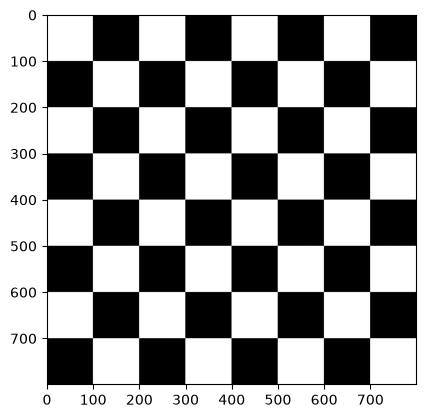

In [ ]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

# se define el tamaño de la imagen
size = 800

# se crea la imagen con todos los valores a 0 y un canal (escala de grises)
table = np.zeros((size, size, 1), dtype=np.uint8)

# bucle anidado para recorrer las "casillas" que equivale a 100x100 pixeles en la imagen
for i in range(8):
    for j in range(8):
        
        # condición para pintar de blanco la casilla
        if (i + j) % 2 == 0:
            table[i*100:(i+1)*100, j*100:(j+1)*100] = 255

# mostrar la imagen
plt.imshow(table, cmap='gray')

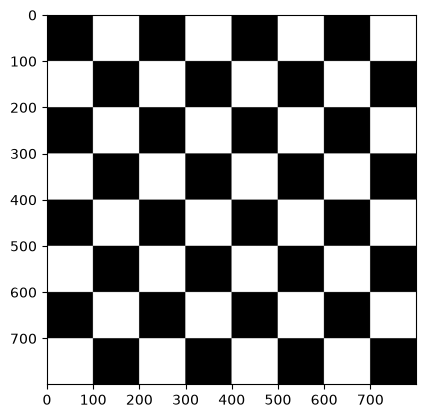

True

In [9]:
# Con IA
import cv2  
import numpy as np
import matplotlib.pyplot as plt

ancho, alto = 800, 800
tam_celda = 100
n_celdas = ancho // tam_celda  # 8

# Patrón 8x8 de 0s y 1s (paridad fila+columna)
patron = (np.indices((n_celdas, n_celdas)).sum(axis=0)) % 2

# Expande cada celda del patrón a un bloque de tam_celda x tam_celda
tablero = np.kron(patron, np.ones((tam_celda, tam_celda))) * 255
tablero = tablero.astype(np.uint8)

plt.imshow(tablero, cmap='gray')
plt.show()

cv2.imwrite('tablero_ajedrez_ia.jpg', tablero)

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

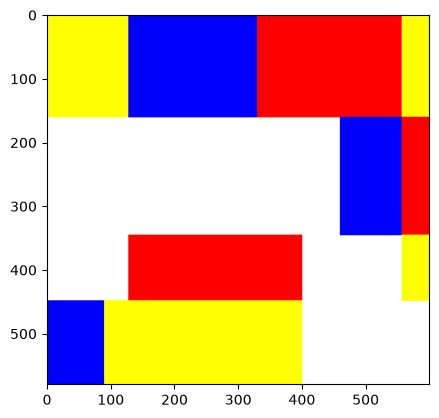

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

W, H = 600, 580
mondrian = np.ones((H, W, 3), dtype=np.uint8) * 255  # fondo blanco

YELLOW = (255, 255, 0)
BLUE = (0, 0, 255)
RED = (255, 0, 0)

# fila superior
cv2.rectangle(mondrian, (0, 0), (128, 160), YELLOW, -1)
cv2.rectangle(mondrian, (128, 0), (330, 160), BLUE, -1)
cv2.rectangle(mondrian, (330, 0), (557, 160), RED, -1)
cv2.rectangle(mondrian, (557, 0), (618, 160), YELLOW, -1)

# fila 2: blanco, luego azul y rojo a la derecha
cv2.rectangle(mondrian, (460, 160), (557, 345), BLUE, -1)
cv2.rectangle(mondrian, (557, 160), (618, 345), RED, -1)

# fila 3: rojo ancho a la izq, amarillo fino a la derecha
cv2.rectangle(mondrian, (128, 345), (400, 448), RED, -1)
cv2.rectangle(mondrian, (557, 345), (618, 448), YELLOW, -1)

# fila 4: azul fino, amarillo ancho, resto blanco
cv2.rectangle(mondrian, (0, 448), (90, 580), BLUE, -1)
cv2.rectangle(mondrian, (90, 448), (400, 580), YELLOW, -1)

plt.imshow(mondrian)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [ ]:
import cv2
import numpy as np

vid = cv2.VideoCapture(0)

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # convertimos a grises para buscar un único valor de intensidad por píxel
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # cv2.minMaxLoc encuentra min/max y sus posiciones en una sola llamada en C (muy rápido)
    minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(gray)

    # círculo verde en el píxel más oscuro, rojo en el más claro
    cv2.circle(frame, minLoc, 15, (0, 255, 0), 2)
    cv2.circle(frame, maxLoc, 15, (0, 0, 255), 2)

    cv2.imshow('Cam', frame)

    if cv2.waitKey(20) == 27:  # esc
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
import cv2
import numpy as np

vid = cv2.VideoCapture(0)

# obtener resolución original de la cámara
orig_w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
orig_h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

# reducimos el tamaño para que quepa todo
w = orig_w // 2
h = orig_h // 2

# lienzo base
collage = np.zeros((h * 3, w * 2, 3), dtype=np.uint8)
tl = collage[0:h, 0:w]
tr = collage[0:h, w:w * 2]

ml = collage[h:h * 2, 0:w]
mr = collage[h:h * 2, w:w * 2]

bl = collage[h * 2:h * 3, 0:w]
br = collage[h * 2:h * 3, w:w * 2]

while True:
    ret, frame = vid.read()
    
    # comprobar siempre antes de procesar el fotograma
    if not ret:
        continue

    # redimensionar al tamaño del cuadrante
    frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_NEAREST)

    # separamos los canales de color
    b = frame[:, :, 0]
    g = frame[:, :, 1]
    r = frame[:, :, 2]

    # todos los cuadrantes
    tl[:] = frame                                      # original
    tr[:] = cv2.merge([255 - b, 255 - g, 255 - r])      # invertido total
    ml[:] = cv2.merge([255 - b, g, r])                  # dominante amarillo
    mr[:] = cv2.merge([b, 255 - g, r])                  # dominante magenta
    bl[:] = cv2.merge([b, g, 255 - r])                  # dominante cian
    br[:] = cv2.merge([255 - g, r, 255 - b])            # canales cruzados

    cv2.imshow("Pop Art", collage)

    if cv2.waitKey(1) & 0xFF == 27: # esc
        break

vid.release()
cv2.destroyAllWindows()